<a href="https://colab.research.google.com/github/khoihole329-sudo/Minhkhoi/blob/main/L%C3%80M%20S%E1%BA%A0CH%20D%E1%BB%AE%20LI%E1%BB%86U%20C%C6%A0%20B%E1%BA%A2N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)

## Câu 1: Khởi tạo dữ liệu (Data Generation)

In [2]:
n = 500
df_khachhang = pd.DataFrame({
    "MaKH": [f"KH{i:03d}" for i in range(1, n + 1)],
    "Tuoi": np.random.randint(18, 71, n).astype(float),
    "ThuNhap": np.random.uniform(5_000_000, 50_000_000, n),
    "GioiTinh": np.random.choice(["Nam", "Nữ"], n),
    "ThanhPho": np.random.choice(["Hà Nội", "Đà Nẵng", "TP.HCM"], n)
})
df_khachhang["TongChiTieu"] = (
    df_khachhang["ThuNhap"] * np.random.uniform(0.15, 0.45, n)
    + np.random.normal(0, 2_000_000, n)
)
df_khachhang.loc[np.random.choice(n, 10, replace=False), "Tuoi"] = np.nan
df_khachhang.loc[np.random.choice(n, 15, replace=False), "GioiTinh"] = np.nan
outlier_idx = np.random.choice(n, 5, replace=False)
df_khachhang.loc[outlier_idx, "ThuNhap"] = np.random.uniform(100_000_000, 200_000_000, 5)
df_khachhang.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu
0,KH001,56.0,2.340288e+07,Nữ,Đà Nẵng,1.787551e+06
1,KH002,69.0,1.279824e+07,Nam,Hà Nội,-1.520807e+05
2,KH003,46.0,1.203967e+07,Nam,TP.HCM,3.557381e+06
3,KH004,32.0,1.626093e+07,Nam,Hà Nội,4.036676e+06
4,KH005,60.0,2.971520e+07,Nam,Đà Nẵng,7.054034e+06


## Câu 2: Xử lý giá trị khuyết (Missing Values)

In [4]:
print("Số lượng giá trị khuyết:")
print(df_khachhang.isnull().sum())
df_khachhang["Tuoi"] = df_khachhang["Tuoi"].fillna(df_khachhang["Tuoi"].median())
df_khachhang["GioiTinh"] = df_khachhang["GioiTinh"].fillna(df_khachhang["GioiTinh"].mode()[0])
print("Sau khi xử lý:")
print(df_khachhang.isnull().sum())

Số lượng giá trị khuyết:
MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64
Sau khi xử lý:
MaKH           0
Tuoi           0
ThuNhap        0
GioiTinh       0
ThanhPho       0
TongChiTieu    0
dtype: int64


## Câu 3: Mã hóa biến phân loại (Categorical Encoding)

In [5]:
thanhpho_encoded = pd.get_dummies(
    df_khachhang["ThanhPho"],
    prefix="ThanhPho",
    dtype=int
)
df_khachhang = pd.concat(
    [df_khachhang, thanhpho_encoded],
    axis=1
)
df_khachhang.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng
0,KH001,56.0,2.340288e+07,Nữ,Đà Nẵng,1.787551e+06,0,0,1
1,KH002,69.0,1.279824e+07,Nam,Hà Nội,-1.520807e+05,1,0,0
2,KH003,46.0,1.203967e+07,Nam,TP.HCM,3.557381e+06,0,1,0
3,KH004,32.0,1.626093e+07,Nam,Hà Nội,4.036676e+06,1,0,0
4,KH005,60.0,2.971520e+07,Nam,Đà Nẵng,7.054034e+06,0,0,1


# Câu 4: Phát hiện và xử lý outlier bằng IQR

In [6]:

Q1 = df_khachhang["ThuNhap"].quantile(0.25)
Q3 = df_khachhang["ThuNhap"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

df_khachhang = df_khachhang[
    (df_khachhang["ThuNhap"] >= lower_bound) &
    (df_khachhang["ThuNhap"] <= upper_bound)
]

df_khachhang.shape

Q1: 16028866.498867858
Q3: 39278644.03504746
Lower bound: -18845799.805401538
Upper bound: 74153310.33931684


(495, 9)

##  Câu 5: Chuẩn hóa TongChiTieu về [0, 1]

In [7]:

scaler = MinMaxScaler()

df_khachhang["TongChiTieu_Scaled"] = scaler.fit_transform(
    df_khachhang[["TongChiTieu"]]
)

df_khachhang[["TongChiTieu", "TongChiTieu_Scaled"]].head()

,TongChiTieu,TongChiTieu_Scaled
0,1.787551e+06,0.160390
1,-1.520807e+05,0.089911
2,3.557381e+06,0.224699
3,4.036676e+06,0.242115
4,7.054034e+06,0.351755


## Câu 6: Lọc dữ liệu theo điều kiện (Data Filtering)

In [8]:
df_loc = df_khachhang[
    (df_khachhang["GioiTinh"] == "Nữ") &
    (df_khachhang["Tuoi"] > 30) &
    (df_khachhang["ThanhPho"] == "Hà Nội")
]

df_loc.head()

,MaKH,Tuoi,ThuNhap,GioiTinh,ThanhPho,TongChiTieu,ThanhPho_Hà Nội,ThanhPho_TP.HCM,ThanhPho_Đà Nẵng,TongChiTieu_Scaled
15,KH016,57.0,3.910307e+07,Nữ,Hà Nội,4.655473e+06,1,0,0,0.264600
22,KH023,61.0,2.633782e+07,Nữ,Hà Nội,8.384643e+06,1,0,0,0.400105
33,KH034,44.0,3.316370e+07,Nữ,Hà Nội,7.965833e+06,1,0,0,0.384887
46,KH047,38.0,2.562138e+07,Nữ,Hà Nội,1.258013e+07,1,0,0,0.552554
48,KH049,56.0,4.736592e+07,Nữ,Hà Nội,1.921097e+07,1,0,0,0.793495


# Câu 7: Groupby thống kê theo ThanhPho

In [9]:
thongke_thanhpho = df_khachhang.groupby("ThanhPho")["TongChiTieu"].agg(["mean", "sum"])

thongke_thanhpho

,mean,sum
ThanhPho,,
Hà Nội,8.358370e+06,1.404206e+09
TP.HCM,7.341526e+06,1.145278e+09
Đà Nẵng,9.235207e+06,1.579220e+09


## Câu 8: Kỹ nghệ đặc trưng (Feature Engineering)


In [10]:
bins = [18, 30, 45, 60, np.inf]
labels = ["18-30", "31-45", "46-60", "Trên 60"]

df_khachhang["NhomTuoi"] = pd.cut(
    df_khachhang["Tuoi"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_khachhang[["Tuoi", "NhomTuoi"]].head()

,Tuoi,NhomTuoi
0,56.0,46-60
1,69.0,Trên 60
2,46.0,46-60
3,32.0,31-45
4,60.0,46-60


## Câu 9: Ma trận tương quan (Correlation Matrix)


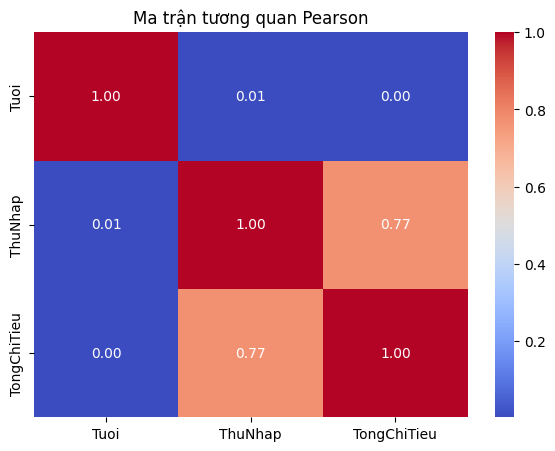

In [11]:
corr_matrix = df_khachhang[["Tuoi", "ThuNhap", "TongChiTieu"]].corr(method="pearson")

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Ma trận tương quan Pearson")
plt.show()

## Câu 10: Trực quan hóa dữ liệu (Data Visualization)

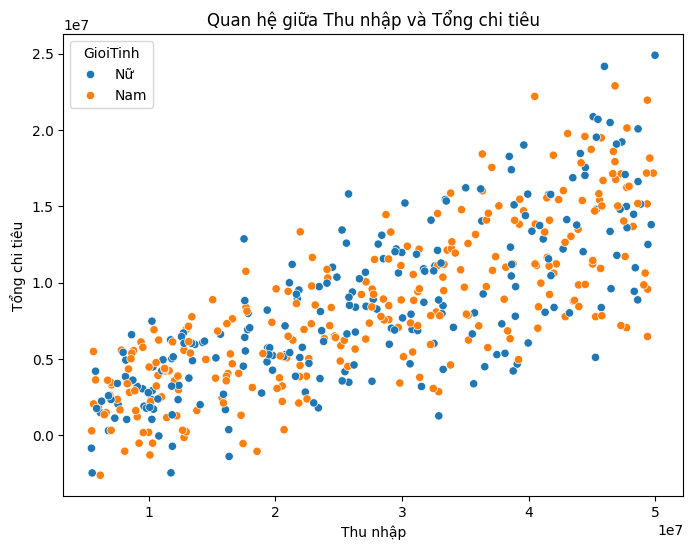

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_khachhang,
    x="ThuNhap",
    y="TongChiTieu",
    hue="GioiTinh"
)

plt.title("Quan hệ giữa Thu nhập và Tổng chi tiêu")
plt.xlabel("Thu nhập")
plt.ylabel("Tổng chi tiêu")
plt.show()

## Câu 11: Xây dựng và Huấn luyện mô hình CNN (Hình ảnh)


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist

In [14]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1
)
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8501 - loss: 0.4266 - val_accuracy: 0.8840 - val_loss: 0.3241
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8955 - loss: 0.2915 - val_accuracy: 0.9017 - val_loss: 0.2745
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9098 - loss: 0.2478 - val_accuracy: 0.9067 - val_loss: 0.2624
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9211 - loss: 0.2185 - val_accuracy: 0.9087 - val_loss: 0.2525
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9296 - loss: 0.1928 - val_accuracy: 0.9097 - val_loss: 0.2506
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9079 - loss: 0.2572
Test Accuracy: 0.9078999757766724
